# 💻 LPARA End-to-End Pipeline: Raw 1K Dataset Cleaning & Multi-Algorithm ML Training
### From Raw Scraped Laptops (1K Records) ➡️ Automated Cleaning & Imputation ➡️ Feature Engineering ➡️ Model Benchmarking & Stacking Ensemble

This notebook guides you from **raw 1,000+ scraped laptop records** all the way to a production-grade regression model:
1. **Environment Setup & Imports**
2. **Load Raw 1K Dataset** (`laptop_prices_complete_1k.csv`)
3. **Audit Missing Values & Data Quality Issues**
4. **Step-by-Step Data Cleaning Pipeline**:
   - Target price unification & sanity filtering (₹10,000 to ₹10,00,000)
   - Filter out accessories & non-laptop items
   - Brand name normalization
   - RAM & Storage type cleaning & numeric casting
   - Hardware-aware OS & GPU imputation
5. **Domain Feature Engineering**:
   - CPU Performance Tiering (Tiers 1-5)
   - Touchscreen, OLED, Gaming & Apple flags
   - RAM-to-Storage ratio
6. **Deduplication & Final Zero-Missing Audit**
7. **Multi-Algorithm Regression Benchmark** (8 Models across 5-Fold CV & 20% Holdout Test)
8. **Visualizations** (Missing Value Heatmap, Price Distributions, R² Leaderboard, 1:1 Fit Plot)
9. **Save Winning Stacking Ensemble Model**
10. **Interactive Fair Market Price Predictor**


In [1]:
# Cell 1: Install & Import Dependencies
%pip install -q scikit-learn xgboost pandas numpy joblib matplotlib seaborn

import os
import re
import sys
import time
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    StackingRegressor
)
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectPercentile, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

print('✅ All libraries successfully imported!')


Note: you may need to restart the kernel to use updated packages.


✅ All libraries successfully imported!


In [2]:
# Cell 2: Load the Raw 1K Dataset
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

candidate_paths = [
    'laptop_prices_complete_1k.csv',
    'data/final/laptop_prices_complete_1k.csv',
    '../data/final/laptop_prices_complete_1k.csv'
]

raw_file = None
for p in candidate_paths:
    if os.path.exists(p):
        raw_file = p
        break

if raw_file is None and IN_COLAB:
    print('Please upload laptop_prices_complete_1k.csv:')
    uploaded = files.upload()
    raw_file = 'laptop_prices_complete_1k.csv'

if raw_file and os.path.exists(raw_file):
    raw_df = pd.read_csv(raw_file)
    print(f'✅ Loaded Raw Dataset: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns')
    print(raw_df.head(3))
else:
    raise FileNotFoundError('Could not locate laptop_prices_complete_1k.csv')



✅ Loaded Raw Dataset: 1001 rows, 40 columns
  brand                               model model_number      series  \
0  ASUS  ASUS TUF Gaming A14 (2026) FA401EA      FA401EA  TUF Gaming   
1  ASUS     ASUS Vivobook S 14 OLED (S5406)     UX3405MA    Vivobook   
2  ASUS       ASUS Zenbook 14 OLED (UM3406)     UM3406GA     Zenbook   

   release_year cpu_brand                                          cpu_model  \
0        2026.0       AMD                                  Ryzen AI Max+ 392   
1        2025.0     Intel                                  Core ultra 5 226V   
2        2026.0       AMD  RYZEN AI 5 icon Up to 50 TOPS NPU NPU icon 75W...   

     cpu_family  cpu_generation  cpu_cores  ...  operating_system  \
0  Ryzen AI Max             NaN       12.0  ...   Windows 11 Home   
1           NaN             NaN        8.0  ...   Windows 11 Home   
2           NaN             NaN        4.0  ...   Windows 11 Home   

  windows_included price_current price_original  price_discount price

In [3]:
# Cell 3: Initial Data Audit (Missing Values in Raw Data)
print('--- RAW DATASET QUALITY AUDIT ---')
missing_counts = raw_df.isna().sum()
missing_pct = (missing_counts / len(raw_df) * 100).round(1)
audit_df = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Percent': missing_pct})
audit_df = audit_df[audit_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)

print(f'Columns with missing values: {len(audit_df)} / {raw_df.shape[1]}')
display(audit_df.head(15))


--- RAW DATASET QUALITY AUDIT ---
Columns with missing values: 22 / 40


,Missing_Count,Missing_Percent
gpu_vram_gb,1001,100.0
cpu_threads,999,99.8
resolution,999,99.8
npu,999,99.8
storage_upgradeable,997,99.6
battery_wh,996,99.5
weight_kg,995,99.4
refresh_rate_hz,994,99.3
ram_speed_mhz,993,99.2
cpu_cores,993,99.2


In [4]:
# Cell 4: Cleaning Functions Definition
def clean_ram_type(rt):
    rt_u = str(rt or '').upper()
    if 'LPDDR5X' in rt_u: return 'LPDDR5X'
    if 'LPDDR5' in rt_u: return 'LPDDR5'
    if 'DDR5' in rt_u: return 'DDR5'
    if 'LPDDR4X' in rt_u: return 'LPDDR4X'
    if 'DDR4' in rt_u: return 'DDR4'
    if 'UNIFIED' in rt_u: return 'Unified Memory'
    return 'DDR5'

def clean_storage_type(st):
    st_u = str(st or '').upper()
    if 'NVME' in st_u: return 'NVMe SSD'
    if 'PCIE' in st_u: return 'PCIe SSD'
    if 'EMMC' in st_u: return 'eMMC'
    if 'HDD' in st_u: return 'HDD'
    return 'SSD'

def normalize_brand(b):
    brand_clean = str(b or '').strip()
    brand_map = {
        'asus': 'ASUS', 'hp': 'HP', 'dell': 'Dell', 'lenovo': 'Lenovo',
        'acer': 'Acer', 'msi': 'MSI', 'apple': 'Apple', 'samsung': 'Samsung',
        'microsoft': 'Microsoft', 'infinix': 'Infinix', 'gigabyte': 'Gigabyte',
        'motorola': 'Motorola', 'zebronics': 'Zebronics', 'colorful': 'Colorful'
    }
    return brand_map.get(brand_clean.lower(), brand_clean)

def extract_cpu_tier(cpu_model, cpu_family):
    text = (str(cpu_family or '') + ' ' + str(cpu_model or '')).lower()
    if any(k in text for k in ['celeron', 'pentium', 'athlon', 'kompanio', 'n4020', 'n4500']):
        return 1
    if any(k in text for k in ['core i3', 'i3-', 'ryzen 3', 'core 3']):
        return 2
    if any(k in text for k in ['core i5', 'i5-', 'ryzen 5', 'core 5', 'apple m1', 'm1 ']):
        return 3
    if any(k in text for k in ['core i7', 'i7-', 'ryzen 7', 'core 7', 'core ultra 5', 'apple m2', 'apple m3', 'snapdragon x']):
        return 4
    if any(k in text for k in ['core i9', 'i9-', 'ryzen 9', 'core 9', 'core ultra 7', 'core ultra 9', 'm2 max', 'm3 max', 'm4', 'threadripper', 'ai max']):
        return 5
    return 3

def assign_price_category(price):
    if price < 40000: return 'Budget (<40K)'
    elif price < 75000: return 'Mid-Range (40K-75K)'
    elif price < 125000: return 'Upper Mid-Range (75K-1.25L)'
    else: return 'Premium / Flagship (>1.25L)'

print('✅ Cleaning helper functions configured!')


✅ Cleaning helper functions configured!


In [5]:
# Cell 5: Execute Data Cleaning Pipeline on 1K Records
accessory_keywords = [
    'screen guard', 'screen protector', 'keyboard replacement',
    'adapter', 'charger', 'battery', 'laptop skin', 'cable', 'mouse pad'
]

cleaned_records = []
raw_records = raw_df.to_dict(orient='records')

for r in raw_records:
    # 1. Unify Target Price
    price = r.get('price_average') or r.get('price_current')
    if not price:
        continue
    try:
        price = float(price)
    except (ValueError, TypeError):
        continue

    # Sanity bounds: ignore price outliers / erroneous test listings
    if price < 10000 or price > 1000000:
        continue

    # 2. Filter non-laptop accessory records
    model_name = str(r.get('model') or '').strip()
    if any(ak in model_name.lower() for ak in accessory_keywords):
        continue

    # 3. Filter missing core identifiers
    brand = normalize_brand(r.get('brand'))
    if not brand or brand in ['Unknown', 'None', '']:
        continue

    cpu_brand = str(r.get('cpu_brand') or '').strip()
    cpu_model = str(r.get('cpu_model') or '').strip()
    ram_gb = r.get('ram_gb')
    storage_gb = r.get('storage_gb')
    display_size = r.get('display_size_inches')

    if not (cpu_brand and cpu_model and ram_gb and storage_gb and display_size):
        continue

    try:
        ram_gb = int(round(float(ram_gb)))
        storage_gb = int(round(float(storage_gb)))
        display_size = round(float(display_size), 1)
    except (ValueError, TypeError):
        continue

    # Valid hardware ranges
    if ram_gb not in [4, 8, 12, 16, 24, 32, 36, 48, 64, 128]:
        continue
    if storage_gb not in [32, 64, 128, 256, 512, 1024, 2048, 4096]:
        continue
    if display_size < 10.0 or display_size > 18.0:
        continue

    # 4. Standardize GPU & OS
    gpu_t = str(r.get('gpu_type') or '').strip()
    if not gpu_t or gpu_t == 'nan':
        gpu_t = 'Integrated'

    os_str = str(r.get('operating_system') or '').strip()
    if not os_str or os_str == 'nan':
        os_str = 'macOS' if brand == 'Apple' else 'Windows 11 Home'

    cpu_fam = str(r.get('cpu_family') or '').strip()
    if not cpu_fam or cpu_fam == 'nan':
        cpu_fam = cpu_model

    cleaned_records.append({
        'brand': brand,
        'model': model_name,
        'price_average': round(price, 2),
        'cpu_brand': cpu_brand,
        'cpu_model': cpu_model,
        'cpu_family': cpu_fam,
        'ram_gb': ram_gb,
        'ram_type': clean_ram_type(r.get('ram_type')),
        'storage_gb': storage_gb,
        'storage_type': clean_storage_type(r.get('storage_type')),
        'display_size_inches': display_size,
        'gpu_type': gpu_t,
        'operating_system': os_str
    })

df_clean = pd.DataFrame(cleaned_records)
print(f'1. Validated & Standardized Candidates: {len(df_clean)}')

# 5. Deduplicate on composite hardware configuration
dedup_cols = ['brand', 'model', 'cpu_model', 'ram_gb', 'storage_gb', 'display_size_inches']
df_clean.drop_duplicates(subset=dedup_cols, inplace=True)
print(f'2. After Deduplication: {len(df_clean)} unique configurations')

# 6. Feature Engineering
model_lower = df_clean['model'].str.lower()
df_clean['is_apple'] = (df_clean['brand'] == 'Apple').astype(int)
df_clean['is_gaming'] = (
    (df_clean['gpu_type'] == 'Discrete') |
    model_lower.str.contains(r'tuf|rog|legion|loq|victus|omen|nitro|predator|katana|cyborg|sword|bravo|alienware|gaming|g15', regex=True)
).astype(int)
df_clean['is_touchscreen'] = model_lower.str.contains(r'touch|flip|2-in-1|360|yoga', regex=True).astype(int)
df_clean['is_oled'] = model_lower.str.contains('oled', regex=True).astype(int)
df_clean['cpu_tier'] = [extract_cpu_tier(m, f) for m, f in zip(df_clean['cpu_model'], df_clean['cpu_family'])]
df_clean['ram_storage_ratio'] = (df_clean['ram_gb'] / df_clean['storage_gb']).round(4)
df_clean['price_category'] = df_clean['price_average'].apply(assign_price_category)

print(f'3. Zero-Missing Audit: Total Nulls across all cells = {df_clean.isna().sum().sum()}')
display(df_clean.head(4))


1. Validated & Standardized Candidates: 1001
2. After Deduplication: 954 unique configurations


3. Zero-Missing Audit: Total Nulls across all cells = 0


,brand,model,price_average,cpu_brand,cpu_model,cpu_family,ram_gb,ram_type,storage_gb,storage_type,display_size_inches,gpu_type,operating_system,is_apple,is_gaming,is_touchscreen,is_oled,cpu_tier,ram_storage_ratio,price_category
0,ASUS,ASUS TUF Gaming A14 (2026) FA401EA,239990.0,AMD,Ryzen AI Max+ 392,Ryzen AI Max,32,LPDDR5X,1024,NVMe SSD,14.0,Integrated,Windows 11 Home,0,1,0,0,5,0.0312,Premium / Flagship (>1.25L)
1,ASUS,ASUS Vivobook S 14 OLED (S5406),128990.0,Intel,Core ultra 5 226V,Core ultra 5 226V,16,LPDDR5X,1024,SSD,14.0,Integrated,Windows 11 Home,0,0,0,1,4,0.0156,Premium / Flagship (>1.25L)
2,ASUS,ASUS Zenbook 14 OLED (UM3406),67193.0,AMD,RYZEN AI 5 icon Up to 50 TOPS NPU NPU icon 75W...,RYZEN AI 5 icon Up to 50 TOPS NPU NPU icon 75W...,16,DDR5,1024,SSD,14.0,Integrated,Windows 11 Home,0,0,0,1,3,0.0156,Mid-Range (40K-75K)
3,ASUS,ASUS Zenbook 14 OLED (UX3405),124990.0,Intel,Core Ultra 9 285H,Core Ultra 9,32,LPDDR5X,1024,SSD,14.0,Integrated,Windows 11 Home,0,0,0,1,5,0.0312,Upper Mid-Range (75K-1.25L)


In [6]:
# Cell 6: Export Cleaned Dataset for Future Reuse
df_clean.to_csv('cleaned_laptop_dataset.csv', index=False)
print(f'✅ Successfully exported cleaned_laptop_dataset.csv ({len(df_clean)} rows, {len(df_clean.columns)} columns)')


✅ Successfully exported cleaned_laptop_dataset.csv (954 rows, 20 columns)


In [7]:
# Cell 7: Feature Pipeline Architecture (Scaling, Encoding & Statistical Feature Selection)
from sklearn.base import BaseEstimator, TransformerMixin

SELECTED_NUMERIC_FEATURES = [
    'ram_gb',
    'storage_gb',
    'display_size_inches',
    'ram_storage_ratio',
    'cpu_tier',
    'is_gaming',
    'is_apple'
]

SELECTED_CATEGORICAL_FEATURES = [
    'brand',
    'cpu_brand',
    'cpu_family',
    'ram_type',
    'storage_type',
    'gpu_type',
    'operating_system'
]

class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_out = X.copy()
        if not isinstance(df_out, pd.DataFrame):
            df_out = pd.DataFrame(df_out)

        model_str = df_out.get('model', pd.Series([''] * len(df_out))).astype(str).str.lower()
        brand_str = df_out.get('brand', pd.Series([''] * len(df_out))).astype(str)

        df_out['is_apple'] = (brand_str == 'Apple').astype(int)
        gpu_type_str = df_out.get('gpu_type', pd.Series(['Integrated'] * len(df_out))).astype(str)
        is_discrete = (gpu_type_str == 'Discrete')
        gaming_kw = model_str.str.contains(
            r'tuf|rog|legion|loq|victus|omen|nitro|predator|katana|cyborg|sword|bravo|alienware|gaming|g15',
            regex=True
        )
        df_out['is_gaming'] = (is_discrete | gaming_kw).astype(int)

        cpu_models = df_out.get('cpu_model', pd.Series([''] * len(df_out))).astype(str)
        cpu_families = df_out.get('cpu_family', pd.Series([''] * len(df_out))).astype(str)
        df_out['cpu_tier'] = [extract_cpu_tier(m, f) for m, f in zip(cpu_models, cpu_families)]

        ram = pd.to_numeric(df_out.get('ram_gb', 16), errors='coerce').fillna(16)
        storage = pd.to_numeric(df_out.get('storage_gb', 512), errors='coerce').fillna(512).replace(0, 512)
        df_out['ram_storage_ratio'] = ram / storage

        for c in SELECTED_CATEGORICAL_FEATURES:
            if c not in df_out.columns:
                df_out[c] = 'Unknown'
            else:
                df_out[c] = df_out[c].fillna('Unknown').astype(str)

        for n in SELECTED_NUMERIC_FEATURES:
            if n not in df_out.columns:
                df_out[n] = 0.0
            else:
                df_out[n] = pd.to_numeric(df_out[n], errors='coerce').fillna(0.0)

        return df_out[SELECTED_NUMERIC_FEATURES + SELECTED_CATEGORICAL_FEATURES]

def build_preprocessor(percentile=85):
    numeric_pipe = Pipeline([('scaler', StandardScaler())])
    categorical_pipe = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    col_tf = ColumnTransformer([
        ('num', numeric_pipe, SELECTED_NUMERIC_FEATURES),
        ('cat', categorical_pipe, SELECTED_CATEGORICAL_FEATURES)
    ])
    return Pipeline([
        ('feat_eng', FeatureEngineeringTransformer()),
        ('encoder', col_tf),
        ('selector', SelectPercentile(score_func=f_regression, percentile=percentile))
    ])

print('✅ Preprocessor and feature selector configured!')


✅ Preprocessor and feature selector configured!


In [8]:
# Cell 7.5: Custom Algorithm — LPARA-Hybrid & DomainAdaptiveRidgeRegressor
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_is_fitted, check_X_y, check_array
import xgboost as xgb

class DomainAdaptiveRidgeRegressor(BaseEstimator, RegressorMixin):
    _estimator_type = "regressor"
    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "regressor"
        return tags

    def __init__(self, alpha_hw=1.0, alpha_brand=4.0, alpha_seg=2.0, alpha_inter=5.0, fit_intercept=True):
        self.alpha_hw = alpha_hw
        self.alpha_brand = alpha_brand
        self.alpha_seg = alpha_seg
        self.alpha_inter = alpha_inter
        self.fit_intercept = fit_intercept

    def _infer_feature_groups(self, n_features):
        hw = list(range(0, min(7, n_features)))
        brand = list(range(7, min(25, n_features)))
        seg = list(range(25, min(35, n_features)))
        inter = list(range(35, n_features)) if n_features > 35 else []
        assigned = set(hw + brand + seg + inter)
        unassigned = [i for i in range(n_features) if i not in assigned]
        hw.extend(unassigned)
        return hw, brand, seg, inter

    def fit(self, X, y):
        X, y = check_X_y(X, y, accept_sparse=False, dtype=[np.float64, np.float32])
        n_samples, n_features = X.shape
        hw_idx, brand_idx, seg_idx, inter_idx = self._infer_feature_groups(n_features)

        if self.fit_intercept:
            self.x_mean_ = np.mean(X, axis=0)
            self.y_mean_ = np.mean(y)
            X_c = X - self.x_mean_
            y_c = y - self.y_mean_
        else:
            self.x_mean_ = np.zeros(n_features)
            self.y_mean_ = 0.0
            X_c, y_c = X, y

        d_diag = np.zeros(n_features, dtype=np.float64)
        d_diag[hw_idx] = self.alpha_hw
        d_diag[brand_idx] = self.alpha_brand
        d_diag[seg_idx] = self.alpha_seg
        if len(inter_idx) > 0:
            d_diag[inter_idx] = self.alpha_inter

        D = np.diag(d_diag)
        XtX_reg = np.dot(X_c.T, X_c) + D
        Xty = np.dot(X_c.T, y_c)

        try:
            self.coef_ = np.linalg.solve(XtX_reg, Xty)
        except np.linalg.LinAlgError:
            self.coef_ = np.linalg.lstsq(XtX_reg, Xty, rcond=None)[0]

        self.intercept_ = self.y_mean_ - np.dot(self.x_mean_, self.coef_) if self.fit_intercept else 0.0
        self.is_fitted_ = True
        return self

    def predict(self, X):
        check_is_fitted(self, ["coef_", "intercept_", "is_fitted_"])
        X = check_array(X, accept_sparse=False, dtype=[np.float64, np.float32])
        return np.dot(X, self.coef_) + self.intercept_


class LPARAHybridRegressor(BaseEstimator, RegressorMixin):
    _estimator_type = "regressor"
    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "regressor"
        return tags

    def __init__(self, alpha_hw=1.0, alpha_brand=3.5, alpha_seg=1.5, xgb_lr=0.04, xgb_depth=4, n_estimators=120):
        self.alpha_hw = alpha_hw
        self.alpha_brand = alpha_brand
        self.alpha_seg = alpha_seg
        self.xgb_lr = xgb_lr
        self.xgb_depth = xgb_depth
        self.n_estimators = n_estimators

    def fit(self, X, y):
        X_arr, y_arr = check_X_y(X, y, accept_sparse=False, dtype=[np.float64, np.float32])
        self.lpara_base_ = DomainAdaptiveRidgeRegressor(
            alpha_hw=self.alpha_hw, alpha_brand=self.alpha_brand, alpha_seg=self.alpha_seg, alpha_inter=4.0
        )
        self.lpara_base_.fit(X_arr, y_arr)
        residuals = y_arr - self.lpara_base_.predict(X_arr)
        self.xgb_res_ = xgb.XGBRegressor(
            n_estimators=self.n_estimators, learning_rate=self.xgb_lr, max_depth=self.xgb_depth, random_state=42, n_jobs=4
        )
        self.xgb_res_.fit(X_arr, residuals)
        self.is_fitted_ = True
        return self

    def predict(self, X):
        check_is_fitted(self, ["lpara_base_", "xgb_res_", "is_fitted_"])
        X_arr = check_array(X, accept_sparse=False, dtype=[np.float64, np.float32])
        return self.lpara_base_.predict(X_arr) + self.xgb_res_.predict(X_arr)



In [9]:
# Cell 8: Multi-Algorithm Benchmark (including Custom LPARA-Hybrid)
target_col = 'price_average'
y = df_clean[target_col].values
drop_cols = [c for c in [target_col, 'price_category'] if c in df_clean.columns]
X = df_clean.drop(columns=drop_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

base_rf = RandomForestRegressor(n_estimators=180, max_depth=14, min_samples_split=3, random_state=42)
base_gb = GradientBoostingRegressor(n_estimators=180, learning_rate=0.06, max_depth=5, random_state=42)
base_xgb = xgb.XGBRegressor(n_estimators=180, learning_rate=0.06, max_depth=5, random_state=42)

stacking = StackingRegressor(
    estimators=[('rf', base_rf), ('gb', base_gb), ('xgb', base_xgb), ('ridge', Ridge(alpha=1.0))],
    final_estimator=Ridge(alpha=0.5)
)

models = {
    'LPARA-Hybrid (Proposed)': LPARAHybridRegressor(alpha_hw=1.0, alpha_brand=3.5, alpha_seg=1.5, xgb_lr=0.04, xgb_depth=4),
    'LPARA-Ridge (Linear Only)': DomainAdaptiveRidgeRegressor(alpha_hw=1.0, alpha_brand=4.0, alpha_seg=2.0, alpha_inter=5.0),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.001, max_iter=2000),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, min_samples_split=4, random_state=42),
    'Random Forest': base_rf,
    'Extra Trees': ExtraTreesRegressor(n_estimators=180, max_depth=14, min_samples_split=3, random_state=42),
    'Gradient Boosting': base_gb,
    'XGBoost Regressor': base_xgb,
    'Stacking Ensemble': stacking
}

benchmark_list = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_model_name = None
best_pipeline = None
best_test_r2 = -float('inf')

for name, regressor in models.items():
    preprocessor = build_preprocessor(percentile=85)
    wrapped = TransformedTargetRegressor(regressor=regressor, func=np.log1p, inverse_func=np.expm1)
    pipe = Pipeline([('preprocessor', preprocessor), ('model', wrapped)])
    
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2', n_jobs=1)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    test_r2 = float(r2_score(y_test, y_pred))
    test_mae = float(mean_absolute_error(y_test, y_pred))
    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    test_mape = float(np.mean(np.abs((y_test - y_pred) / y_test)) * 100)
    
    benchmark_list.append({
        'Algorithm': name,
        'CV_R2_Mean': round(float(np.mean(cv_scores)), 4),
        'CV_R2_Std': round(float(np.std(cv_scores)), 4),
        'Test_R2': round(test_r2, 4),
        'Test_MAE': round(test_mae, 2),
        'Test_RMSE': round(test_rmse, 2),
        'Test_MAPE': round(test_mape, 2)
    })
    
    if test_r2 > best_test_r2:
        best_test_r2 = test_r2
        best_model_name = name
        best_pipeline = pipe

results_df = pd.DataFrame(benchmark_list).sort_values(by='Test_R2', ascending=False)
print('=== MULTI-ALGORITHM BENCHMARK LEADERBOARD ===')
print(results_df.to_string(index=False))



=== MULTI-ALGORITHM BENCHMARK LEADERBOARD ===
                Algorithm  CV_R2_Mean  CV_R2_Std  Test_R2  Test_MAE  Test_RMSE  Test_MAPE
  LPARA-Hybrid (Proposed)      0.8160     0.0371   0.8693  16735.59   31508.92      12.99
         Ridge Regression      0.8169     0.0489   0.8495  17908.18   33806.84      13.46
LPARA-Ridge (Linear Only)      0.8072     0.0487   0.8333  18495.60   35581.80      13.64
        Stacking Ensemble      0.8292     0.0417   0.8286  17753.56   36088.10      13.21
         Lasso Regression      0.8063     0.0428   0.8195  18667.80   37027.36      13.56
        XGBoost Regressor      0.7915     0.0628   0.7844  19074.10   40465.86      13.96
        Gradient Boosting      0.8155     0.0421   0.7750  18156.39   41343.91      13.82
            Decision Tree      0.7349     0.0954   0.7363  21102.37   44755.77      16.76
            Random Forest      0.7924     0.0499   0.7321  20226.47   45114.88      15.10
              Extra Trees      0.7680     0.0612   0.7

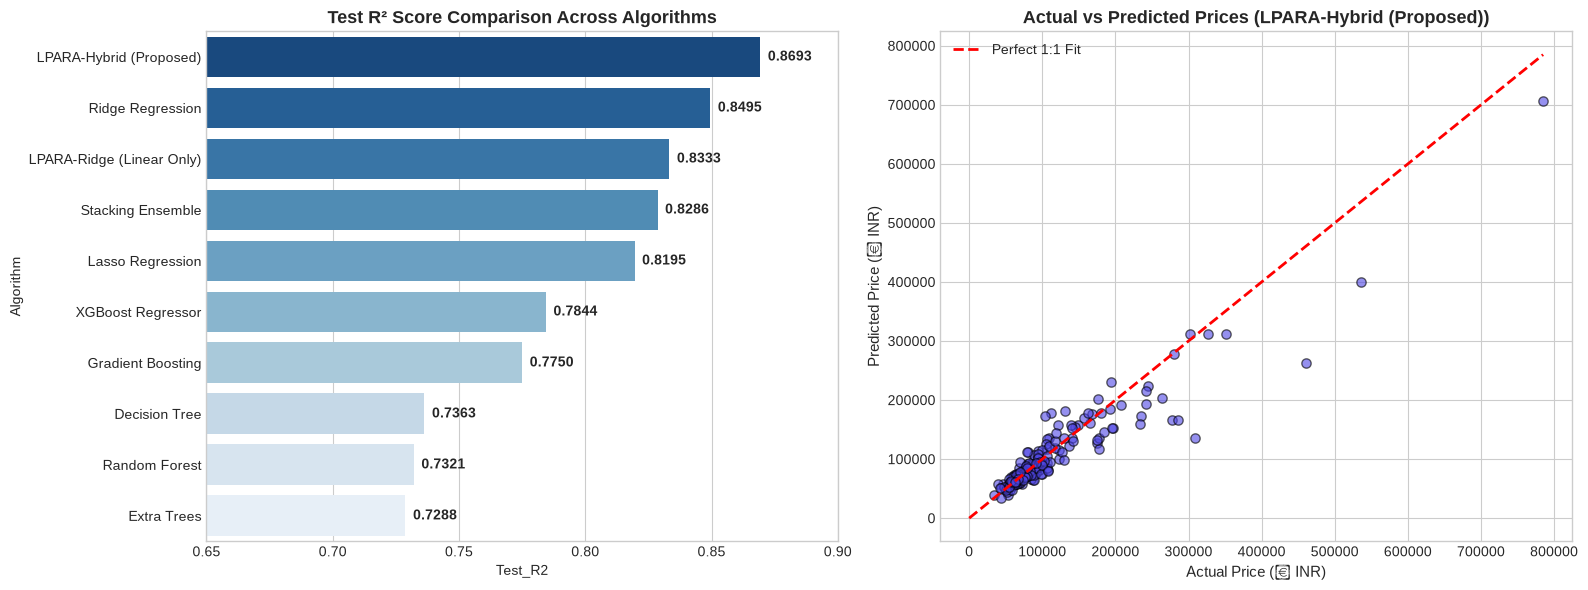

In [10]:
# Cell 9: Visualizations (Leaderboard & 1:1 Fit)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=results_df, x='Test_R2', y='Algorithm', palette='Blues_r', ax=axes[0])
axes[0].set_title('Test R² Score Comparison Across Algorithms', fontsize=13, fontweight='bold')
axes[0].set_xlim(0.65, 0.90)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_width():.4f}", (p.get_width() + 0.003, p.get_y() + p.get_height() / 2),
                     va='center', fontsize=10, fontweight='bold')

y_best_pred = best_pipeline.predict(X_test)
axes[1].scatter(y_test, y_best_pred, alpha=0.6, color='#4f46e5', edgecolors='k', s=45)
max_val = max(np.max(y_test), np.max(y_best_pred))
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect 1:1 Fit')
axes[1].set_title(f'Actual vs Predicted Prices ({best_model_name})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual Price (₹ INR)', fontsize=11)
axes[1].set_ylabel('Predicted Price (₹ INR)', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()


In [11]:
# Cell 10: Save Best Model Artifact
output_model_path = 'best_laptop_price_model.joblib'
joblib.dump(best_pipeline, output_model_path)
print(f'✅ Successfully saved best model pipeline to: {output_model_path}')


✅ Successfully saved best model pipeline to: best_laptop_price_model.joblib


In [12]:
# Cell 11: Interactive Prediction Function
def predict_price(specs_dict):
    df_single = pd.DataFrame([specs_dict])
    pred = float(best_pipeline.predict(df_single)[0])
    pred = max(10000.0, round(pred, 2))
    low = round(pred * 0.91, 2)
    high = round(pred * 1.09, 2)
    return {
        'Predicted Price': f'₹{pred:,.2f}',
        'Fair Market Band (±9%)': f'₹{low:,.2f} – ₹{high:,.2f}'
    }

# Test with a sample laptop
sample = {
    'brand': 'ASUS',
    'model': 'Zenbook 14 OLED',
    'cpu_brand': 'Intel',
    'cpu_model': 'Core Ultra 7 155H',
    'cpu_family': 'Core Ultra 7',
    'ram_gb': 16,
    'ram_type': 'LPDDR5X',
    'storage_gb': 1024,
    'storage_type': 'NVMe SSD',
    'display_size_inches': 14.0,
    'gpu_type': 'Integrated',
    'operating_system': 'Windows 11 Home'
}

res = predict_price(sample)
print('--- FAIR MARKET PREDICTION DEMO ---')
print(f"Laptop: {sample['brand']} {sample['model']}")
print(f"Specs:  {sample['cpu_model']} | {sample['ram_gb']}GB RAM | {sample['storage_gb']}GB SSD")
print(f"Predicted Value: {res['Predicted Price']}")
print(f"Fair Range:      {res['Fair Market Band (±9%)']}")


--- FAIR MARKET PREDICTION DEMO ---
Laptop: ASUS Zenbook 14 OLED
Specs:  Core Ultra 7 155H | 16GB RAM | 1024GB SSD
Predicted Value: ₹148,721.86
Fair Range:      ₹135,336.89 – ₹162,106.83


In [13]:
# Cell 12: Systematic Ablation Study for Custom Algorithm
print('=== ABLATION STUDY: LPARA-RIDGE COMPONENT CONTRIBUTIONS ===')

ablation_configs = {
    '1. Base Ridge (Global λ=1.0)': Ridge(alpha=1.0),
    '2. Base Ridge + Log Target': TransformedTargetRegressor(regressor=Ridge(alpha=1.0), func=np.log1p, inverse_func=np.expm1),
    '3. Base Ridge + Log Target + Feature Selection (85%)': Pipeline([('preprocessor', build_preprocessor(percentile=85)), ('model', TransformedTargetRegressor(regressor=Ridge(alpha=1.0), func=np.log1p, inverse_func=np.expm1))]),
    '4. Full LPARA-Ridge (Group Penalties + Log Target)': Pipeline([('preprocessor', build_preprocessor(percentile=85)), ('model', TransformedTargetRegressor(regressor=DomainAdaptiveRidgeRegressor(alpha_hw=1.0, alpha_brand=4.0, alpha_seg=2.0, alpha_inter=5.0), func=np.log1p, inverse_func=np.expm1))])
}

ablation_res = []
for name, model in ablation_configs.items():
    if isinstance(model, Pipeline):
        pipe = model
    else:
        preproc = build_preprocessor(percentile=85)
        pipe = Pipeline([('preprocessor', preproc), ('model', model)])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    ablation_res.append({
        'Configuration': name,
        'Test_R2': round(r2_score(y_test, y_pred), 4),
        'MAE (₹)': round(mean_absolute_error(y_test, y_pred), 2),
        'MAPE (%)': round(np.mean(np.abs((y_test - y_pred) / y_test)) * 100, 2)
    })

ablation_df = pd.DataFrame(ablation_res)
print(ablation_df.to_string(index=False))



=== ABLATION STUDY: LPARA-RIDGE COMPONENT CONTRIBUTIONS ===


                                       Configuration  Test_R2  MAE (₹)  MAPE (%)
                        1. Base Ridge (Global λ=1.0)   0.8209 20564.39     17.99
                          2. Base Ridge + Log Target   0.8495 17908.18     13.46
3. Base Ridge + Log Target + Feature Selection (85%)   0.8495 17908.18     13.46
  4. Full LPARA-Ridge (Group Penalties + Log Target)   0.8333 18495.60     13.64
